__Librairy imports__

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import seaborn as sns

from supervisedlearning.linearregression import LinRegression
from enums.costfunctions import CostFunctions

from unsupervisedlearning.kmeans import KMeans

__Importing Data__

In [2]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [3]:
# df = pd.get_dummies(housing, columns = ['ocean_proximity'], drop_first = True, dtype = int)
# df = df.dropna()
# train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)
# print(df.columns)
# rel = df[['median_house_value', 'median_income']]
print(1)

1


## __Supervised Learning__
### __Linear Regression__

Importing Linear Regression test data

In [9]:
ads = pd.read_csv('datasets/Advertising.csv')

# splitting into train and test set
train_set, test_set = train_test_split(ads, test_size = 0.2, random_state = 42)

In [10]:
# formatting a test value
def formatting_testing(test_set):
    testing_true_value = test_set.iloc[4]['sales']
    testing = test_set.drop(columns = 'sales').iloc[4]
    testing = testing.to_numpy()
    testing = np.insert(testing, 0, 1, axis=0)
    return testing, testing_true_value
testing, testing_true_value = formatting_testing(test_set)

RMSE of model is: 1.0699463759704548
Predicted value: 22.492917090721207 |  Actual value: 24.7


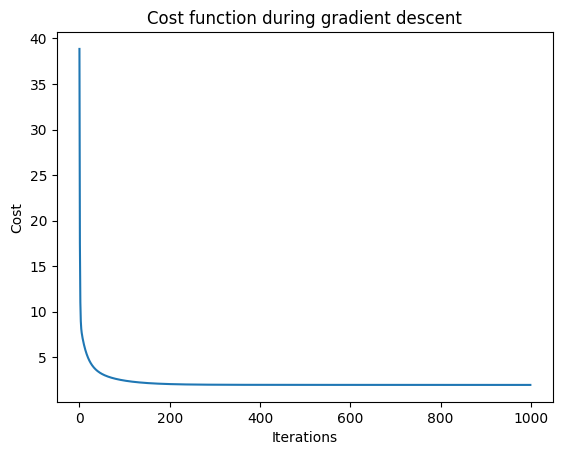

In [ ]:
# creating our model
linR_model = LinRegression(
    trainset = train_set,
    testset = test_set,
    target = 'sales',
    learning_rate = 0.00005
    )

# applying our gradient descent
linR_model.gradientdescent()
print(f'RMSE of model is: {linR_model.RMSE_calculation()}')
print(f'Predicted value: {linR_model.make_prediction(testing)} | ', f'Actual value: {testing_true_value}')
linR_model.plot_error_function()


Comparing with Scikit Learn's Linear Regression

In [18]:
# formatting data set to use scikit learns Linear Regression
comparative_x = ads.drop(columns = 'sales')
comparative_x = comparative_x.to_numpy()
comparative_x = np.insert(comparative_x, 0, 1, axis=1)
comparative_y = ads['sales'].to_numpy()

# splitting data
x_train, x_test, y_train, y_test = train_test_split(comparative_x, comparative_y, test_size= 0.2, random_state= 42)

# fitting out the model
comparative_model = LinearRegression()
comparative_model.fit(x_train, y_train)
y_train_pred = comparative_model.predict(x_train)
y_test_pred = comparative_model.predict(x_test)

# computing RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


print(f'RMSE of Scikit Learns model: {rmse}')
print(f'Predicted value: {comparative_model.predict(testing.reshape(1, -1))[0]}')



RMSE of Scikit Learns model: 1.781599661533451
Predicted value: 22.11237325985766


## __Unsupervised Learning__
### __K means clustering__

Importing k means test data

In [10]:
from sklearn.datasets import load_iris

data = load_iris()

x = data.data
y = data.target
x_2d = x[:,:3]


In [13]:
iris = load_iris(as_frame= True)
logistic_x = iris.data[['petal width (cm)']].values
logistic_y = iris.target_names[iris.target] == 'virginica'

print(logistic_y)

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]


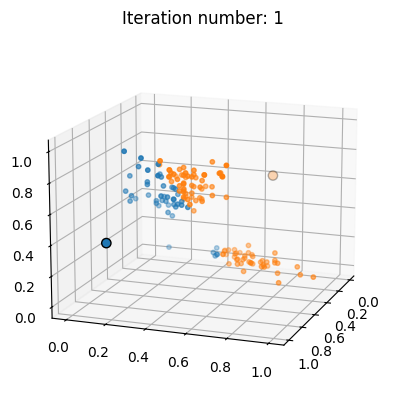

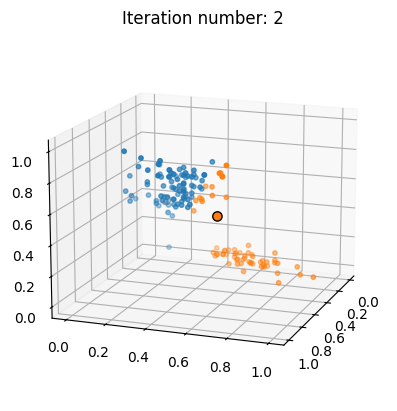

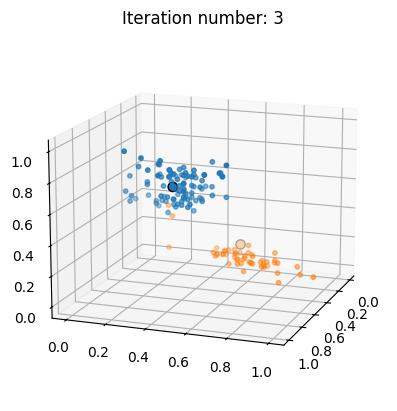

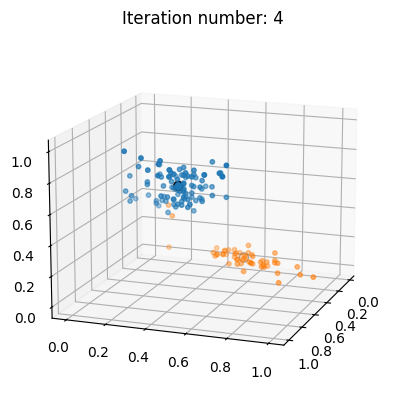

In [6]:
# Applying our k means model for the iris model
kmeans_iris = KMeans(data = x_2d, k = 2)

#applying our clustering
kmeans_iris.algorithm()

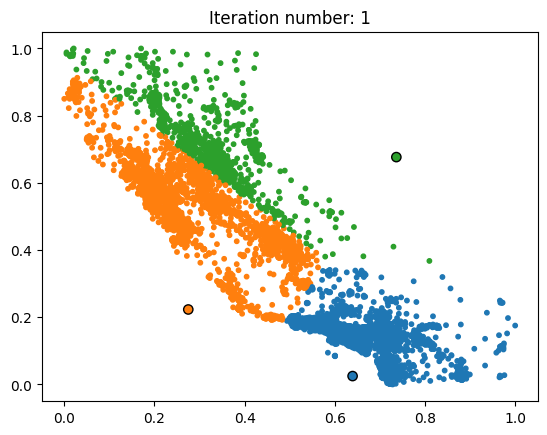

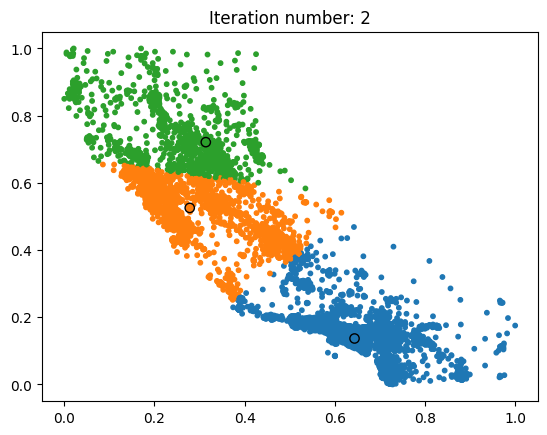

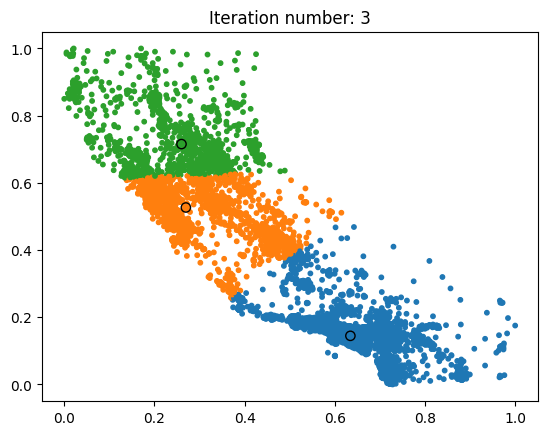

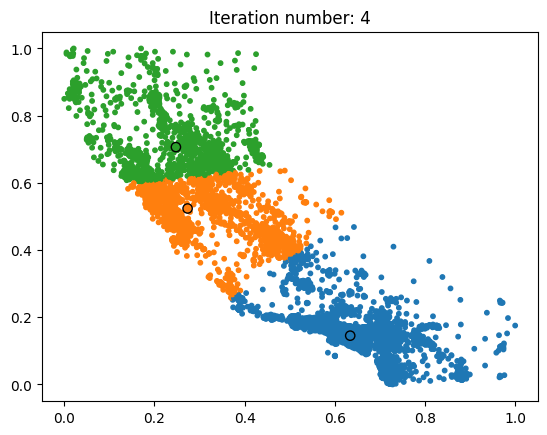

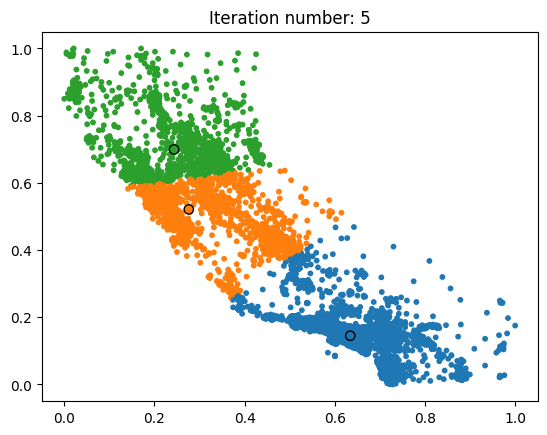

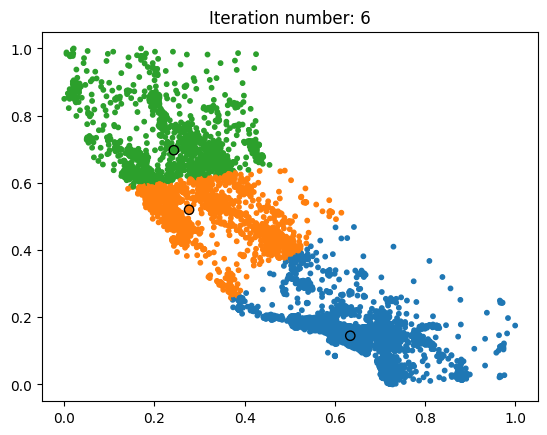

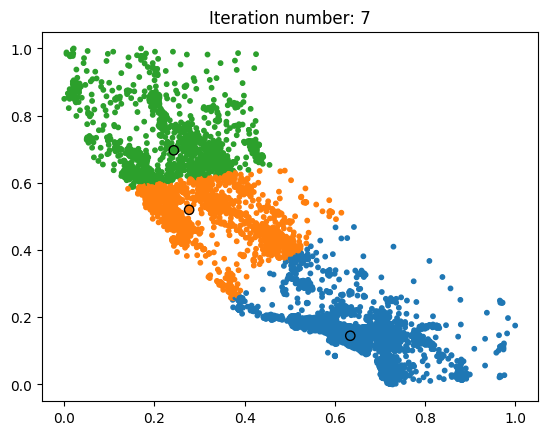

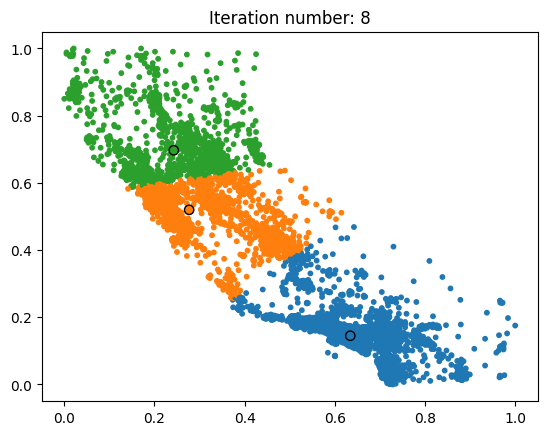

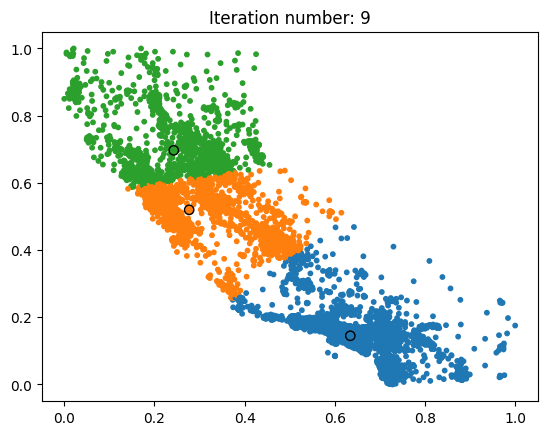

In [ ]:
# Applying our k means to housing data
xy_housing = housing[['longitude','latitude']]
xy_housing = np.array(xy_housing)

kmeans_housing = KMeans(data = xy_housing, k = 3)
kmeans_housing.algorithm()